<a href="https://colab.research.google.com/github/Kanishk877777/ML_Repo/blob/master/ODIR5K.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()

Saving kaggle (2).json to kaggle (2).json


{'kaggle (2).json': b'{"username":"kg2005dev","key":"58331c492d1163087cb3fc5ac28c9116"}'}

In [ ]:
!pip install -q kaggle

In [ ]:
!ls

'kaggle (2).json'   sample_data


In [ ]:
!mkdir -p ~/.kaggle
!cp "kaggle (2).json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d andrewmvd/ocular-disease-recognition-odir5k

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/ocular-disease-recognition-odir5k
License(s): other
 99% 1.60G/1.62G [00:12<00:00, 210MB/s]
100% 1.62G/1.62G [00:12<00:00, 143MB/s]


In [ ]:
!unzip -q ocular-disease-recognition-odir5k.zip

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
import pandas as pd
df = pd.read_excel("/content/ODIR-5K/ODIR-5K/data.xlsx")
df.head()

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O
0,0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0
1,1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0
2,2,42,Male,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,1
3,3,66,Male,3_left.jpg,3_right.jpg,normal fundus,branch retinal artery occlusion,0,0,0,0,0,0,0,1
4,4,53,Male,4_left.jpg,4_right.jpg,macular epiretinal membrane,mild nonproliferative retinopathy,0,1,0,0,0,0,0,1


In [ ]:
df.shape

(3500, 15)

In [ ]:
df.columns

Index(['ID', 'Patient Age', 'Patient Sex', 'Left-Fundus', 'Right-Fundus',
       'Left-Diagnostic Keywords', 'Right-Diagnostic Keywords', 'N', 'D', 'G',
       'C', 'A', 'H', 'M', 'O'],
      dtype='object')

In [ ]:
import os
base_path = "ODIR-5K/ODIR-5K"
img_dir = os.path.join(base_path, "Training Images")

df = pd.read_excel(os.path.join(base_path, "data.xlsx"))

df=df[['Left-Fundus','Right-Fundus','N','D','G','C','A','H','M','O']]
df=df.dropna()
df.shape
df

,Left-Fundus,Right-Fundus,N,D,G,C,A,H,M,O
0,0_left.jpg,0_right.jpg,0,0,0,1,0,0,0,0
1,1_left.jpg,1_right.jpg,1,0,0,0,0,0,0,0
2,2_left.jpg,2_right.jpg,0,1,0,0,0,0,0,1
3,3_left.jpg,3_right.jpg,0,0,0,0,0,0,0,1
4,4_left.jpg,4_right.jpg,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...
3495,4686_left.jpg,4686_right.jpg,0,1,0,0,0,0,0,0
3496,4688_left.jpg,4688_right.jpg,0,1,0,0,0,0,0,0
3497,4689_left.jpg,4689_right.jpg,0,1,0,0,0,0,0,0
3498,4690_left.jpg,4690_right.jpg,0,1,0,0,0,0,0,0


In [ ]:
df = df.head(100)
df

,Left-Fundus,Right-Fundus,N,D,G,C,A,H,M,O
0,0_left.jpg,0_right.jpg,0,0,0,1,0,0,0,0
1,1_left.jpg,1_right.jpg,1,0,0,0,0,0,0,0
2,2_left.jpg,2_right.jpg,0,1,0,0,0,0,0,1
3,3_left.jpg,3_right.jpg,0,0,0,0,0,0,0,1
4,4_left.jpg,4_right.jpg,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...
95,95_left.jpg,95_right.jpg,0,0,1,0,0,1,0,0
96,96_left.jpg,96_right.jpg,0,1,0,0,0,0,0,1
97,97_left.jpg,97_right.jpg,0,0,0,0,0,0,0,1
98,98_left.jpg,98_right.jpg,0,0,0,0,0,0,0,1


In [ ]:
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

print("Train size:", len(train_df))
print("Val size:", len(val_df))

Train size: 80
Val size: 20


In [ ]:
from torchvision import transforms
transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [ ]:
import os
from PIL import Image
from torch.utils.data import Dataset
import torch.nn as nn
import torchvision.models as models
class ODIRDualDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        left_path = os.path.join(self.img_dir, row['Left-Fundus'])
        right_path = os.path.join(self.img_dir, row['Right-Fundus'])

        left_img = Image.open(left_path).convert("RGB")
        right_img = Image.open(right_path).convert("RGB")

        labels = row[['N','D','G','C','A','H','M','O']].values.astype(float)

        if self.transform:
            left_img = self.transform(left_img)
            right_img = self.transform(right_img)

        return left_img, right_img, torch.tensor(labels, dtype=torch.float32)

In [ ]:
from torch.utils.data import Dataset, DataLoader
train_dataset = ODIRDualDataset(train_df, img_dir, transform)
val_dataset = ODIRDualDataset(val_df, img_dir, transform)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True,num_workers=2,pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [ ]:
class DualResNet(nn.Module):
    def __init__(self):
        super(DualResNet, self).__init__()

        self.backbone = models.resnet18(pretrained=True)
        self.backbone.fc = nn.Identity()

        self.classifier = nn.Sequential(
            nn.Linear(512 * 2, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 8)
        )

    def forward(self, left_img, right_img):
        left_feat = self.backbone(left_img)
        right_feat = self.backbone(right_img)

        combined = torch.cat((left_feat, right_feat), dim=1)
        output = self.classifier(combined)

        return output

model = DualResNet().to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
labels = train_df[['N','D','G','C','A','H','M','O']]

pos_counts = labels.sum()
neg_counts = len(labels) - pos_counts

pos_weight = neg_counts / pos_counts
pos_weight = torch.tensor(pos_weight.values, dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

In [ ]:
for param in model.backbone.parameters():
    param.requires_grad = False

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for left, right, labels in loader:
        left, right, labels = left.to(device), right.to(device), labels.to(device)

        outputs = model(left, right)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
train_losses = []
for epoch in range(6):
    loss = train_one_epoch(model, train_loader)
    train_losses.append(loss)
    print(f"Stage 1 Epoch {epoch+1}, Loss: {loss:.4f}")

Stage 1 Epoch 1, Loss: 1.1717
Stage 1 Epoch 2, Loss: 1.1034
Stage 1 Epoch 3, Loss: 1.0998
Stage 1 Epoch 4, Loss: 1.0282
Stage 1 Epoch 5, Loss: 1.0506
Stage 1 Epoch 6, Loss: 0.9758


In [ ]:
for param in model.backbone.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

for epoch in range(9):
    loss = train_one_epoch(model, train_loader)
    print(f"Stage 2 Epoch {epoch+1}, Loss: {loss:.4f}")

Stage 2 Epoch 1, Loss: 0.7798
Stage 2 Epoch 2, Loss: 0.7557
Stage 2 Epoch 3, Loss: 0.7236
Stage 2 Epoch 4, Loss: 0.7194
Stage 2 Epoch 5, Loss: 0.6905
Stage 2 Epoch 6, Loss: 0.6813
Stage 2 Epoch 7, Loss: 0.6410
Stage 2 Epoch 8, Loss: 0.6263
Stage 2 Epoch 9, Loss: 0.6090


In [ ]:
def predict(model, loader):
    model.eval()
    all_probs = []
    all_preds = []

    with torch.no_grad():
        for left, right, labels in loader:
            left = left.to(device)
            right = right.to(device)

            outputs = model(left, right)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            all_probs.append(probs.cpu())
            all_preds.append(preds.cpu())

    return torch.cat(all_probs), torch.cat(all_preds)

In [ ]:
probs, preds = predict(model, val_loader)

print("Probabilities shape:", probs.shape)
print("Predictions shape:", preds.shape)

Probabilities shape: torch.Size([20, 8])
Predictions shape: torch.Size([20, 8])


In [ ]:
class_names = ['Normal','Diabetes','Glaucoma','Cataract',
               'AMD','Hypertension','Myopia','Other']

for i in range(10):  # show first 5 samples
    print(f"\nSample {i}")
    for j, val in enumerate(preds[i]):
        if val == 1:
            print(class_names[j], f"({probs[i][j]:.2f})")


Sample 0
✓ Hypertension (0.55)
✓ Myopia (0.62)

Sample 1
✓ Diabetes (0.59)

Sample 2
✓ Diabetes (0.53)
✓ Other (0.56)

Sample 3
✓ Diabetes (0.56)
✓ Hypertension (0.50)
✓ Other (0.51)

Sample 4
✓ Diabetes (0.57)

Sample 5
✓ AMD (0.52)
✓ Myopia (0.66)

Sample 6
✓ Diabetes (0.55)
✓ Cataract (0.52)
✓ Other (0.52)

Sample 7
✓ Diabetes (0.65)
✓ Other (0.52)

Sample 8
✓ Normal (0.68)
✓ Diabetes (0.58)

Sample 9
✓ Other (0.57)


In [ ]:
from sklearn.metrics import f1_score, roc_auc_score
import matplotlib.pyplot as plt
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for left, right, labels in val_loader:
        left, right = left.to(device), right.to(device)

        outputs = model(left, right)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_preds.append(preds.cpu())
        all_labels.append(labels)

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

print("Macro F1:", f1_score(all_labels, all_preds, average='macro'))
print("Micro F1:", f1_score(all_labels, all_preds, average='micro'))
print("ROC-AUC:", roc_auc_score(all_labels, all_preds, average='macro'))

Macro F1: 0.21595071595071594
Micro F1: 0.5294117647058824
ROC-AUC: nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


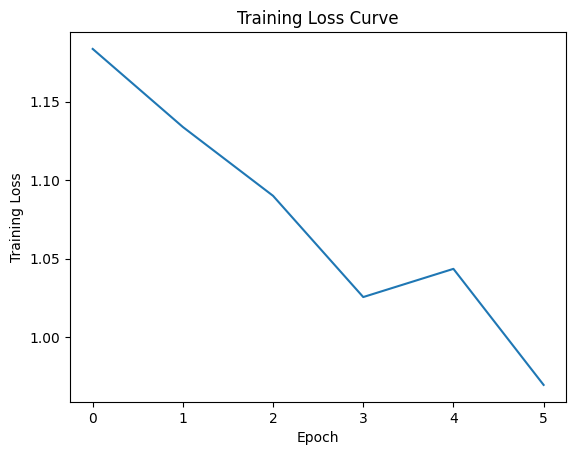

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")
plt.show()